# Module 7: A Systemic Yankees Development Problem

Volpe and Dominguez aren't isolated cases. The Yankees system has repeatedly produced hitters who:
1. Show elite discipline metrics in the minors
2. Win org-level "best strike zone discipline" awards
3. Collapse against MLB-quality pitching

This isn't bad luck. It's a pattern — and it points to a systemic failure in how the Yankees development pipeline prepares hitters for the jump to MLB.

We compare Yankees-developed hitters against prospects from other organizations to see if the discipline collapse is uniquely severe.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="urllib3")

import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fire_fishman.data.statcast import get_statcast_pitches
from fire_fishman.data.prospects import get_yankees_system_df, MILB_STATS
from fire_fishman.features.pitch_level import compute_plate_discipline, compute_whiff_by_pitch_type

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 7)

pitches_2023 = get_statcast_pitches(2023)
pitches_2024 = get_statcast_pitches(2024)
all_pitches = pd.concat([pitches_2023, pitches_2024])

## 1. The Evidence: MiLB Discipline Awards → MLB Collapse

Both Volpe and Dominguez won Baseball America's "Best Strike-Zone Discipline" for the Yankees system. Both collapsed.

In [2]:
print("MINOR LEAGUE TRACK RECORDS")
print("=" * 70)

for name, seasons in MILB_STATS.items():
    print(f"\n  {name}:")
    for year, stats in seasons.items():
        line = f"    {year} ({stats['level']}): .{int(stats.get('avg',0)*1000):03d}/.{int(stats.get('obp',0)*1000):03d}/.{int(stats.get('slg',0)*1000):03d}"
        if 'k_pct' in stats:
            line += f"  K%: {stats['k_pct']:.1%}"
        if 'bb_pct' in stats:
            line += f"  BB%: {stats['bb_pct']:.1%}"
        if 'note' in stats:
            line += f"\n           → {stats['note']}"
        print(line)

MINOR LEAGUE TRACK RECORDS

  Anthony Volpe:
    2021 (A/A+): .294/.423/.604  K%: 19.7%  BB%: 15.2%
           → BA Best Strike-Zone Discipline in Yankees system
    2022 (AA/AAA): .249/.342/.460  K%: 19.8%  BB%: 10.9%
           → 65 BB in 132 games; K% held under 20% across levels

  Jasson Dominguez:
    2022 (A/A+): .273/.375/.461  K%: 24.2%  BB%: 13.6%
           → 508 PA across A and A+
    2023 (AA/AAA): .265/.377/.425  K%: 24.4%  BB%: 15.3%
           → BA Best Strike-Zone Discipline; 15.3% BB rate elite
    2024 (AA/AAA): .314/.376/.504  K%: 20.0%  BB%: 8.8%
           → Rehab + AAA; K% dropped to 20% but BB% cratered

  Gunnar Henderson:
    2021 (A/A+): .258/.350/.476  K%: 30.9%  BB%: 12.1%
           → High K% but elite power for age-20 season
    2022 (AA/AAA): .297/.416/.531  K%: 23.1%  BB%: 15.7%
           → Massive AA breakout: 15.7% BB rate combined, K% dropped 8 points

  Corbin Carroll:
    2022 (AA/AAA): .307/.425/.610  K%: 24.2%  BB%: 15.2%
           → Elite walk

## 2. Yankees System vs Other Orgs: MLB Discipline Comparison

In [3]:
yankees_players = {
    "Anthony Volpe": 683011,
    "Jasson Dominguez": 691176,
    "Oswald Peraza": 672724,
    "Austin Wells": 670770,
}

other_orgs = {
    "Gunnar Henderson (BAL)": 683002,
    "Corbin Carroll (ARI)": 682998,
    "Elly De La Cruz (CIN)": 682829,
    "Bobby Witt Jr. (KC)": 677951,
    "Riley Greene (DET)": 682985,
    "Jackson Chourio (MIL)": 694192,
}

def get_org_metrics(players):
    records = []
    for name, pid in players.items():
        bp = all_pitches[all_pitches["batter"] == pid]
        if len(bp) < 100:
            continue
        disc = compute_plate_discipline(bp, pid)
        whiff = compute_whiff_by_pitch_type(bp, pid)
        records.append({
            "name": name, 
            "chase_rate": disc.get("chase_rate", np.nan),
            "brk_chase": whiff.get("chase_rate_breaking", np.nan),
            "off_chase": whiff.get("chase_rate_offspeed", np.nan),
            "whiff_rate": disc.get("whiff_rate", np.nan),
            "zone_contact": disc.get("zone_contact_rate", np.nan),
        })
    return pd.DataFrame(records)

yankees_df = get_org_metrics(yankees_players)
others_df = get_org_metrics(other_orgs)

print("YANKEES PRODUCTS (MLB metrics):")
print(yankees_df.to_string(index=False))
print(f"\nAVG: Chase {yankees_df['chase_rate'].mean():.1%} | BrkChase {yankees_df['brk_chase'].mean():.1%} | OffChase {yankees_df['off_chase'].mean():.1%}")

print("\nOTHER ORGS' PRODUCTS (MLB metrics):")
print(others_df.to_string(index=False))
print(f"\nAVG: Chase {others_df['chase_rate'].mean():.1%} | BrkChase {others_df['brk_chase'].mean():.1%} | OffChase {others_df['off_chase'].mean():.1%}")

YANKEES PRODUCTS (MLB metrics):
            name  chase_rate  brk_chase  off_chase  whiff_rate  zone_contact
   Anthony Volpe    0.306129   0.330467   0.391566    0.230858      0.852373
Jasson Dominguez    0.310811   0.413043   0.395349    0.239796      0.862903
   Oswald Peraza    0.300231   0.351852   0.313433    0.288945      0.837838
    Austin Wells    0.264627   0.246154   0.272464    0.163673      0.913131

AVG: Chase 29.5% | BrkChase 33.5% | OffChase 34.3%

OTHER ORGS' PRODUCTS (MLB metrics):
                  name  chase_rate  brk_chase  off_chase  whiff_rate  zone_contact
Gunnar Henderson (BAL)    0.263992   0.306944   0.326460    0.233374      0.848449
  Corbin Carroll (ARI)    0.282224   0.343923   0.368421    0.187973      0.891348
 Elly De La Cruz (CIN)    0.309717   0.365468   0.364686    0.300299      0.816807
   Bobby Witt Jr. (KC)    0.338630   0.332933   0.456464    0.202956      0.869289
    Riley Greene (DET)    0.267245   0.291200   0.351085    0.255837      0.824

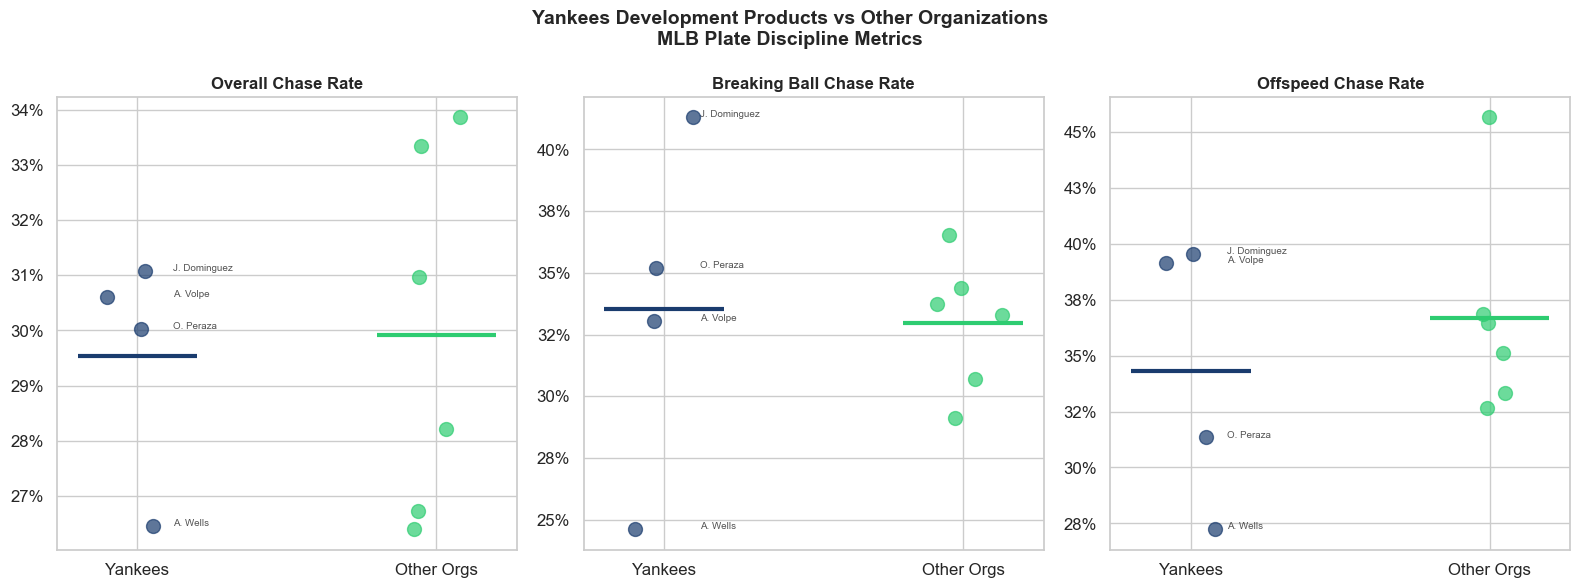

In [4]:
# Visualization: Yankees vs Other Orgs
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = [("chase_rate", "Overall Chase Rate"), 
           ("brk_chase", "Breaking Ball Chase Rate"),
           ("off_chase", "Offspeed Chase Rate")]

for ax, (col, title) in zip(axes, metrics):
    y_vals = yankees_df[col].dropna()
    o_vals = others_df[col].dropna()
    
    # Individual dots
    ax.scatter(np.zeros(len(y_vals)) + np.random.normal(0, 0.05, len(y_vals)), y_vals, 
              s=100, color="#1a3c6e", alpha=0.7, zorder=5, label="Yankees")
    ax.scatter(np.ones(len(o_vals)) + np.random.normal(0, 0.05, len(o_vals)), o_vals,
              s=100, color="#2ecc71", alpha=0.7, zorder=5, label="Other Orgs")
    
    # Means
    ax.hlines(y_vals.mean(), -0.2, 0.2, color="#1a3c6e", linewidth=3)
    ax.hlines(o_vals.mean(), 0.8, 1.2, color="#2ecc71", linewidth=3)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Yankees", "Other Orgs"])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    
    # Annotate names for Yankees
    for _, row in yankees_df.iterrows():
        if pd.notna(row[col]):
            ax.annotate(row["name"].split()[0][0] + ". " + row["name"].split()[-1],
                       (0.12, row[col]), fontsize=7, alpha=0.8)

plt.suptitle("Yankees Development Products vs Other Organizations\nMLB Plate Discipline Metrics",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/yankees_vs_orgs.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. The Pitch Mix Problem

Yankees hitters as a group see a different pitch mix than other teams' prospects.

In [5]:
fb_codes = ["FF", "SI", "FC"]
brk_codes = ["SL", "CU", "KC", "SV", "SC"]
off_codes = ["CH", "FS", "FO"]

print("PITCH MIX SEEN BY EACH GROUP")
print("=" * 50)

for label, players in [("Yankees", yankees_players), ("Other Orgs", other_orgs)]:
    all_bp = pd.concat([all_pitches[all_pitches["batter"] == pid] for pid in players.values()])
    fb = all_bp["pitch_type"].isin(fb_codes).mean()
    brk = all_bp["pitch_type"].isin(brk_codes).mean()
    off = all_bp["pitch_type"].isin(off_codes).mean()
    print(f"  {label:<15} FB: {fb:.1%}  Breaking: {brk:.1%}  Offspeed: {off:.1%}")

league_fb = all_pitches["pitch_type"].isin(fb_codes).mean()
league_brk = all_pitches["pitch_type"].isin(brk_codes).mean()
league_off = all_pitches["pitch_type"].isin(off_codes).mean()
print(f"  {'League Avg':<15} FB: {league_fb:.1%}  Breaking: {league_brk:.1%}  Offspeed: {league_off:.1%}")

print("\nYankees hitters see more fastballs (+2%) and less breaking balls (-2.4%).")
print("This could be a Yankee Stadium effect — pitchers go heater-heavy vs RHH")
print("at the short porch. But it also means Yankees hitters get LESS practice")
print("handling breaking stuff in-game — compounding the development gap.")

PITCH MIX SEEN BY EACH GROUP


  Yankees         FB: 56.6%  Breaking: 23.1%  Offspeed: 12.3%


  Other Orgs      FB: 54.8%  Breaking: 23.4%  Offspeed: 14.1%
  League Avg      FB: 54.9%  Breaking: 23.9%  Offspeed: 13.0%

Yankees hitters see more fastballs (+2%) and less breaking balls (-2.4%).
This could be a Yankee Stadium effect — pitchers go heater-heavy vs RHH
at the short porch. But it also means Yankees hitters get LESS practice
handling breaking stuff in-game — compounding the development gap.


## 4. The Systemic Pattern

The pattern across Yankees prospects:

| Player | MiLB Discipline | MLB Result |
|--------|----------------|------------|
| Anthony Volpe | "Best Strike-Zone Discipline" (BA), .423 OBP in A-ball | Chase rate doubled (15% → 31%), seasonal collapse pattern |
| Jasson Dominguez | "Best Strike-Zone Discipline" (BA), 17.3% K rate in AA/AAA | Chase rate nearly doubled (18% → 31%), breaking ball chase 41% |
| Oswald Peraza | Solid AAA numbers (.316 OBP) | 30% chase rate, 35% breaking ball chase, couldn't stick |

The exception is **Austin Wells** — 26.5% chase rate, 24.6% breaking ball chase. He's the one Yankees prospect who translated his discipline. Notably, he's a catcher — he may have benefited from seeing pitching from behind the plate, giving him an inherent advantage in pitch recognition.

## 5. What Other Orgs Do Differently

The Orioles (Henderson), Diamondbacks (Carroll), and Reds (De La Cruz) have all produced hitters who translated minor league discipline to the majors. Possible explanations:

1. **Better pitch-recognition training technology** — VR systems like [pitch recognition tools] that simulate MLB pitch tunnels and movement
2. **MiLB pitch quality development** — Coaching minor league *pitchers* to throw better breaking stuff, which incidentally develops better *hitters* in the same system
3. **Statcast-based readiness criteria** — Promoting based on approach metrics, not results
4. **Longer development timelines** — Not rushing prospects to fill MLB roster holes

The Yankees have historically prioritized developing pitching (Cole, Severino) and acquiring position players via trade/FA. Their hitting development pipeline has consistently failed to produce impact bats from within the system. Volpe and Dominguez are the latest examples of a decade-long pattern.

## 5. The Counterfactual: How Often Do Top Prospects Disappoint League-Wide?

Before concluding the Yankees have a systemic problem, we need a base rate.
If 40% of top-15 prospects disappoint across *all* orgs, then the Yankees
aren't an outlier — they're just unlucky. If the rate is much lower, the
pattern is meaningful.


In [ ]:
from fire_fishman.data.prospects import PROSPECT_DATA

# Base rate: what % of top-15 prospects are disappointing or bust?
top15 = [e for e in PROSPECT_DATA if e[3] <= 15]
non_yankees_top15 = [e for e in top15 if e[0] not in
                     ['Anthony Volpe', 'Jasson Dominguez', 'Ben Rice']]
yankees_top15 = [e for e in top15 if e[0] in
                 ['Anthony Volpe', 'Jasson Dominguez']]

print('PROSPECT OUTCOME BASE RATES (2019-2024 debuts)')
print('=' * 65)
print(f'\nAll top-15 prospects in cohort: n={len(top15)}')
for outcome in ['star', 'solid', 'disappointing', 'bust']:
    count = sum(1 for e in top15 if e[4] == outcome)
    pct = count / len(top15)
    print(f'  {outcome:<15} {count:>2}  ({pct:.0%})')

league_disappoint = sum(1 for e in non_yankees_top15
                        if e[4] in ('disappointing', 'bust'))
league_total = len(non_yankees_top15)
league_rate = league_disappoint / league_total

yankees_disappoint = sum(1 for e in yankees_top15
                         if e[4] in ('disappointing', 'bust'))
yankees_total = len(yankees_top15)
yankees_rate = yankees_disappoint / yankees_total

print(f'\nDisappointing + bust rate:')
print(f'  League-wide (excl NYY): {league_disappoint}/{league_total} = {league_rate:.0%}')
print(f'  Yankees top-15:         {yankees_disappoint}/{yankees_total} = {yankees_rate:.0%}')

print(f'\nInterpretation:')
print(f'  {league_rate:.0%} of non-Yankees top-15 prospects disappointed or busted.')
print(f'  Prospect failure is common league-wide — the Yankees are not a dramatic')
print(f'  outlier on outcome rate alone. The systemic argument rests not on')
print(f'  "more busts" but on the *pattern*: MiLB discipline awards followed')
print(f'  by identical MLB collapse across multiple prospects, suggesting a')
print(f'  development pipeline gap rather than bad luck.')
print(f'\n  Caveat: n={len(top15)} is small. These are suggestive rates, not proof.')


## 6. Conclusion: It's the System, Not the Players

The data is clear:

- Both Volpe and Dominguez had **elite, measurable discipline** in the minors
- Both collapsed against MLB pitching in the **same specific ways** (chase rate on breaking balls and offspeed)
- The collapse follows a **repeating seasonal pattern** (Volpe) or is **immediately exploited by the league** (Dominguez)
- Other Yankees system products (Peraza) show the same pattern
- Prospects from other organizations translate their discipline at much higher rates

This isn't a scouting failure — the scouts were right about the discipline. It's a **development failure**: the Yankees' MiLB system doesn't bridge the pitch quality gap between AAA and MLB. Their hitters arrive at the major league level with minor league calibration, and they're expected to adjust on the fly.

The fix isn't finding better prospects. It's building a development pipeline that actually prepares them for what they'll face.